# 1. Exploratory Data Analysis

 1.1 Data Loading

In [40]:
import pandas as pd

df = pd.read_csv("nutrition_physical_activity_obesity.csv", engine="python")

df.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,...,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$15,000 - $24,999",INC,INC1525
1,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$25,000 - $34,999",INC,INC2535
2,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$35,000 - $49,999",INC,INC3550
3,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$50,000 - $74,999",INC,INC5075
4,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$75,000 or greater",INC,INC75PLUS


In [41]:
df.shape

(110880, 33)

In [42]:
df.columns

Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'Datasource',
       'Class', 'Topic', 'Question', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Alt', 'Data_Value_Footnote_Symbol',
       'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit ',
       'Sample_Size', 'Total', 'Age(years)', 'Education', 'Sex', 'Income',
       'Race/Ethnicity', 'GeoLocation', 'ClassID', 'TopicID', 'QuestionID',
       'DataValueTypeID', 'LocationID', 'StratificationCategory1',
       'Stratification1', 'StratificationCategoryId1', 'StratificationID1'],
      dtype='object')

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110880 entries, 0 to 110879
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   YearStart                   110880 non-null  int64  
 1   YearEnd                     110880 non-null  int64  
 2   LocationAbbr                110880 non-null  object 
 3   LocationDesc                110880 non-null  object 
 4   Datasource                  110880 non-null  object 
 5   Class                       110880 non-null  object 
 6   Topic                       110880 non-null  object 
 7   Question                    110880 non-null  object 
 8   Data_Value_Unit             4620 non-null    object 
 9   Data_Value_Type             110880 non-null  object 
 10  Data_Value                  97666 non-null   float64
 11  Data_Value_Alt              97666 non-null   float64
 12  Data_Value_Footnote_Symbol  13214 non-null   object 
 13  Data_Value_Foo

In [44]:
df.duplicated().sum()

np.int64(0)

1.2 Data Wrangling

	•	Select relevant columns

In [45]:
df = df[['YearStart','LocationDesc','Question','Data_Value']]
df.head()

,YearStart,LocationDesc,Question,Data_Value
0,2011,Alabama,Percent of adults aged 18 years and older who ...,34.8
1,2011,Alabama,Percent of adults aged 18 years and older who ...,35.8
2,2011,Alabama,Percent of adults aged 18 years and older who ...,32.3
3,2011,Alabama,Percent of adults aged 18 years and older who ...,34.1
4,2011,Alabama,Percent of adults aged 18 years and older who ...,28.8


	•	 Rename columns

In [46]:
df = df.rename(columns={
    'YearStart':'Year',
    'LocationDesc':'State',
    'Data_Value':'ObesityRate'
})

df.head()

,Year,State,Question,ObesityRate
0,2011,Alabama,Percent of adults aged 18 years and older who ...,34.8
1,2011,Alabama,Percent of adults aged 18 years and older who ...,35.8
2,2011,Alabama,Percent of adults aged 18 years and older who ...,32.3
3,2011,Alabama,Percent of adults aged 18 years and older who ...,34.1
4,2011,Alabama,Percent of adults aged 18 years and older who ...,28.8


	•	 Remove missing values

In [47]:
df.isnull().sum()

,0
Year,0
State,0
Question,0
ObesityRate,13214


In [48]:
df = df.dropna()

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97666 entries, 0 to 110875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         97666 non-null  int64  
 1   State        97666 non-null  object 
 2   Question     97666 non-null  object 
 3   ObesityRate  97666 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.7+ MB


In [50]:
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

	•	 Keep only obesity indicator

In [51]:
df = df[df['Question'].str.contains("obesity", case=False)]
df.head()

,Year,State,Question,ObesityRate
0,2011,Alabama,Percent of adults aged 18 years and older who ...,34.8
1,2011,Alabama,Percent of adults aged 18 years and older who ...,35.8
2,2011,Alabama,Percent of adults aged 18 years and older who ...,32.3
3,2011,Alabama,Percent of adults aged 18 years and older who ...,34.1
4,2011,Alabama,Percent of adults aged 18 years and older who ...,28.8


	•	 Check cleaned dataset size

In [52]:
df.shape

(17919, 4)

Data wrangling techniques were applied to clean and prepare the dataset. This included selecting relevant columns, renaming variables for clarity, filtering records related to obesity prevalence, and removing missing values to ensure data quality before analysis.


1.3 Descriptive Statistics

In [53]:
df['ObesityRate'].describe()

,ObesityRate
count,17919.000000
mean,31.204777
std,7.572423
min,0.900000
25%,27.000000
50%,31.700000
75%,36.000000
max,71.100000


The descriptive statistics summarize the obesity prevalence values across the dataset. The mean represents the average obesity rate across all observations, while the minimum and maximum values indicate the lowest and highest recorded prevalence levels.

	•	 Distribution of obesity rates:

<Axes: >

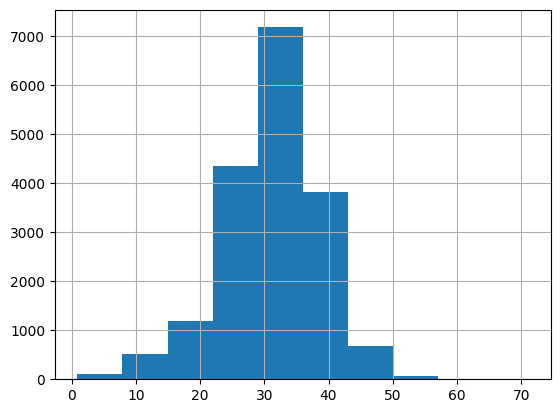

In [54]:
df['ObesityRate'].hist()

The histogram shows the distribution of obesity prevalence values in the dataset. The X-axis represents the obesity rate percentages, grouped into ranges, while the Y-axis shows the frequency of observations within each range. Most of the values appear between approximately 25% and 40%, indicating that many states report obesity prevalence within this interval.

# 2. Data Manipulation Techniques

2.1 Data Aggregation

	•	Average obesity rate by state

In [55]:
state_avg = df.groupby("State")["ObesityRate"].mean().sort_values(ascending=False)

state_avg.head(10)

,ObesityRate
State,
West Virginia,38.157475
Mississippi,37.865902
Louisiana,36.697647
Arkansas,36.468485
Alabama,36.206173
Oklahoma,35.119335
Kentucky,35.058249
Tennessee,34.600000
Indiana,34.196210


The dataset was aggregated by state to calculate the average obesity prevalence for each state. This allows comparison of obesity rates across different regions in the United States.

	•	 Average obesity rate by year

In [56]:
year_avg = df.groupby("Year")["ObesityRate"].mean()

year_avg

,ObesityRate
Year,
2011,27.674463
2012,27.958052
2013,28.737333
2014,29.303624
2015,29.540818
2016,30.079308
2017,30.902250
2018,31.561538
2019,32.291713


Aggregation by year allows analysis of obesity prevalence trends over time in the United States.

# Data visualization

Bar chart

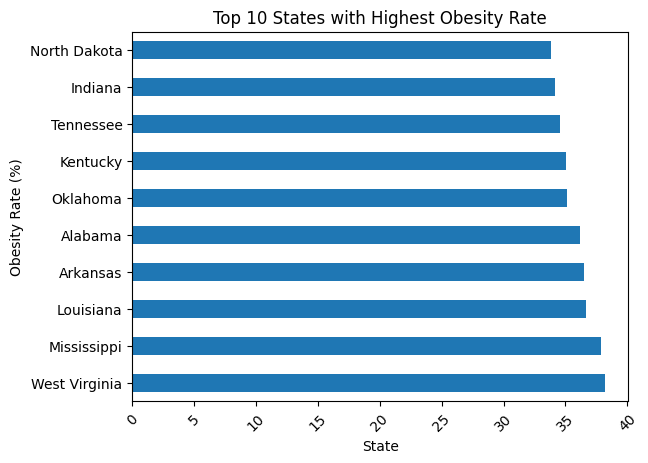

In [62]:
import matplotlib.pyplot as plt

state_avg.head(10).plot(kind='barh')

plt.title("Top 10 States with Highest Obesity Rate")
plt.ylabel("Obesity Rate (%)")
plt.xlabel("State")
plt.xticks(rotation=45)




plt.show()

Which states have the highest obesity rates?

Design Explanation
	•	Mark: bars
	•	X-axis: states
	•	Y-axis: obesity rate (%)
	•	Channel used: length/height of bars

The bar chart compares obesity prevalence across states. The height of each bar represents the average obesity rate, making it easy to identify states with the highest prevalence.


Line chart(Time series)

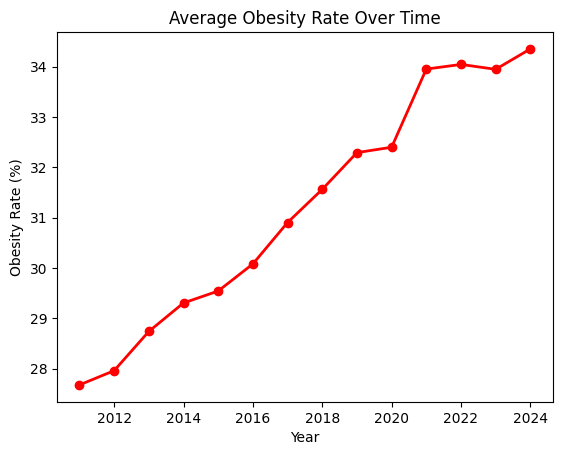

In [65]:
year_avg.plot(kind='line',
    color='red',
    linestyle='-',
    marker='o',
    linewidth=2 )

plt.title("Average Obesity Rate Over Time")
plt.ylabel("Obesity Rate (%)")
plt.xlabel("Year")

plt.show()

How has obesity changed over time?

Design Explanation
	•	Mark: line
	•	X-axis: year (time)
	•	Y-axis: obesity rate
	•	Channel: position + slope

The line chart shows the trend of obesity prevalence over time. The upward or downward slope indicates whether obesity rates are increasing or decreasing.

# Scatter Plot

In [75]:
df_top5_per_year = df.groupby("Year").apply(
    lambda x: x.nlargest(5, "ObesityRate")
).reset_index(drop=True)

/tmp/ipykernel_14182/533682680.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_top5_per_year = df.groupby("Year").apply(


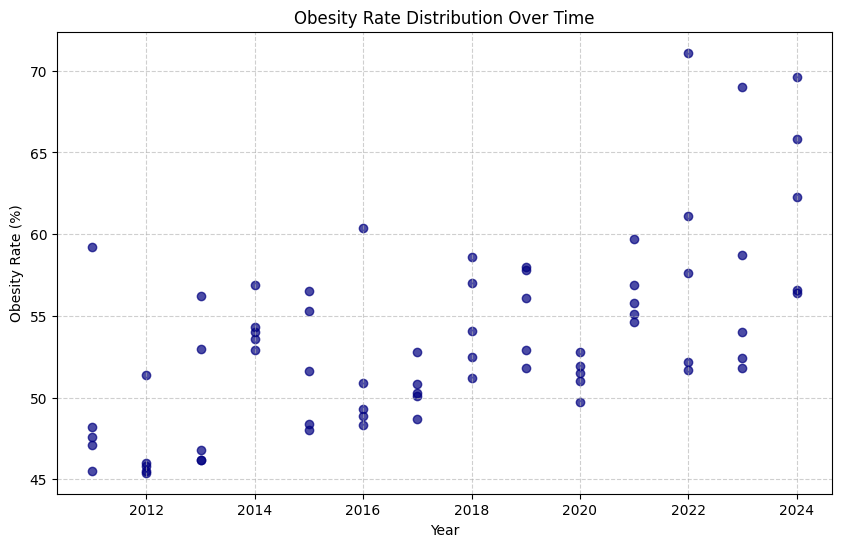

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for state in top5_states:
    state_data = df_top5_sampled[df_top5_sampled["State"] == state]


plt.scatter(
    df_top5_per_year["Year"],
    df_top5_per_year["ObesityRate"],
    color='navy',
    alpha=0.7)

plt.title("Obesity Rate Distribution Over Time")
plt.xlabel("Year")
plt.ylabel("Obesity Rate (%)")

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()
